In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Dataset .csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (9551, 21)


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [3]:
print(df.columns.tolist())

df.info()

['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Aggregate rating', 'Rating color', 'Rating text', 'Votes']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null  

In [4]:
print(df.isnull().sum())

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64


In [5]:
print(df[['Latitude','Longitude']].describe())

          Latitude    Longitude
count  9551.000000  9551.000000
mean     25.854381    64.126574
std      11.007935    41.467058
min     -41.330428  -157.948486
25%      28.478713    77.081343
50%      28.570469    77.191964
75%      28.642758    77.282006
max      55.976980   174.832089


In [6]:
city_counts = df['City'].value_counts().head(10)

print(city_counts)

City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Amritsar          21
Ahmedabad         21
Lucknow           21
Guwahati          21
Name: count, dtype: int64


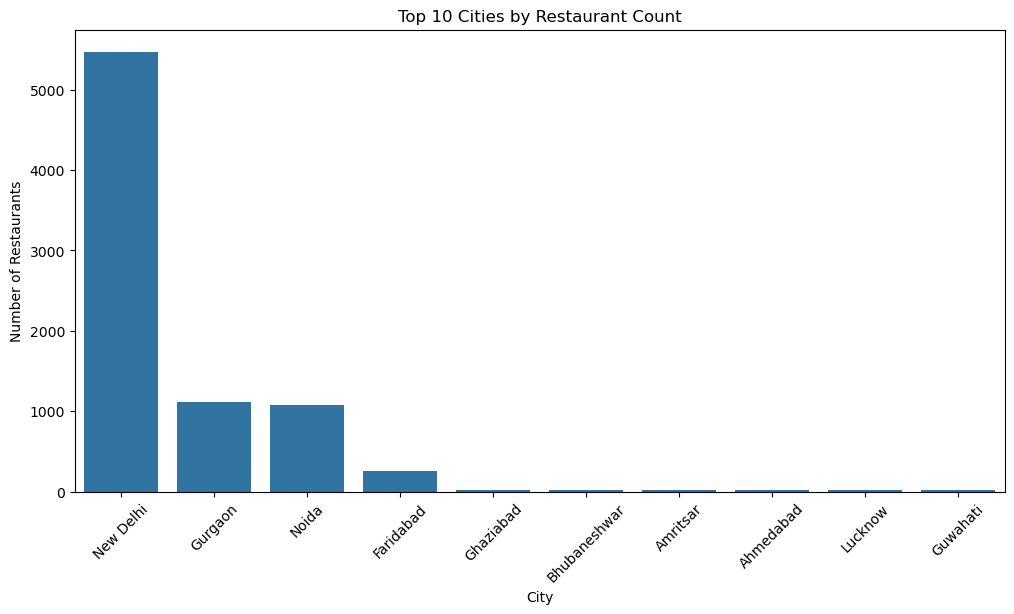

In [7]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=city_counts.index,
    y=city_counts.values
)

plt.title("Top 10 Cities by Restaurant Count")
plt.xlabel("City")
plt.ylabel("Number of Restaurants")

plt.xticks(rotation=45)

plt.show()

In [8]:
city_rating = df.groupby('City')['Aggregate rating'].mean()

city_rating = city_rating.sort_values(
    ascending=False
).head(10)

print(city_rating)

City
Inner City          4.900000
Quezon City         4.800000
Makati City         4.650000
Pasig City          4.633333
Mandaluyong City    4.625000
Beechworth          4.600000
London              4.535000
Taguig City         4.525000
Tagaytay City       4.500000
Secunderabad        4.500000
Name: Aggregate rating, dtype: float64


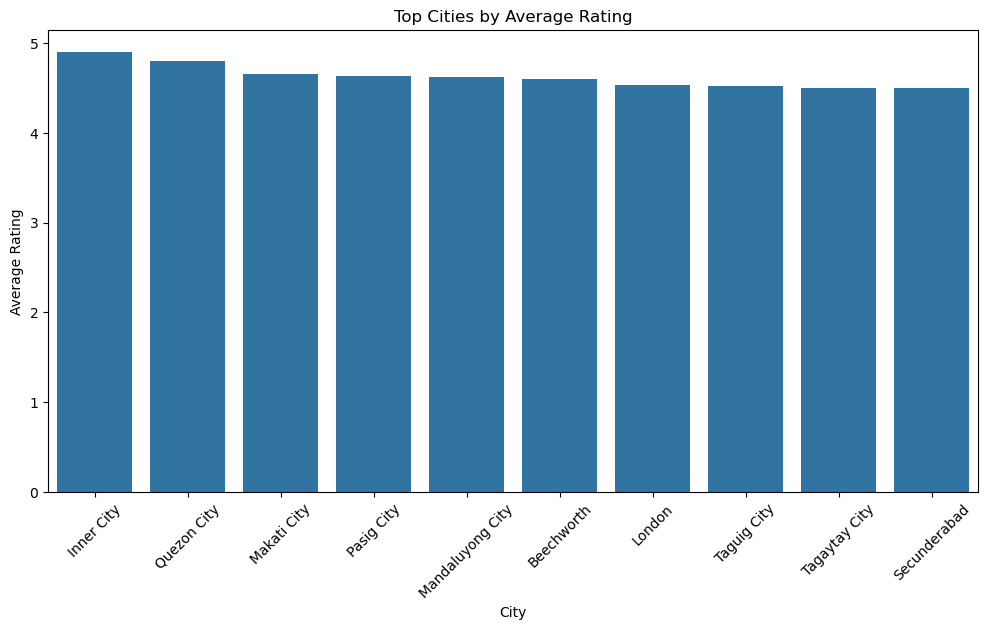

In [9]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=city_rating.index,
    y=city_rating.values
)

plt.title("Top Cities by Average Rating")
plt.xlabel("City")
plt.ylabel("Average Rating")

plt.xticks(rotation=45)

plt.show()

In [10]:
city_cost = df.groupby('City')['Average Cost for two'].mean()

city_cost = city_cost.sort_values(
    ascending=False
).head(10)

print(city_cost)

City
Jakarta             308437.500000
Tangerang           250000.000000
Bogor               160000.000000
Bandung             150000.000000
Pasay City            3333.333333
Colombo               2375.000000
Mandaluyong City      2000.000000
Panchkula             2000.000000
Taguig City           1725.000000
Hyderabad             1361.111111
Name: Average Cost for two, dtype: float64


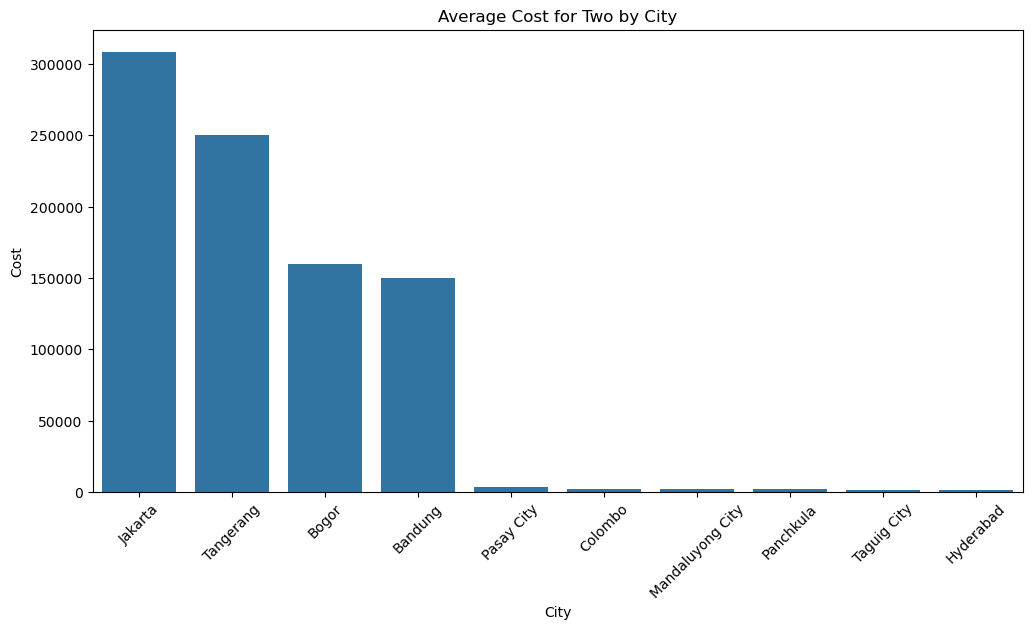

In [11]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=city_cost.index,
    y=city_cost.values
)

plt.title("Average Cost for Two by City")
plt.xlabel("City")
plt.ylabel("Cost")

plt.xticks(rotation=45)

plt.show()

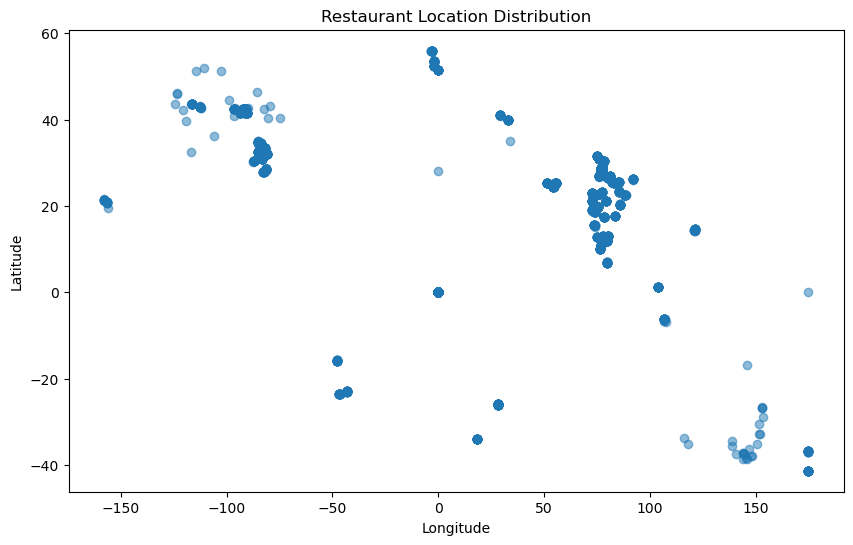

In [12]:
plt.figure(figsize=(10,6))

plt.scatter(
    df['Longitude'],
    df['Latitude'],
    alpha=0.5
)

plt.title("Restaurant Location Distribution")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

In [13]:
locality_counts = df['Locality'].value_counts().head(10)

print(locality_counts)

Locality
Connaught Place        122
Rajouri Garden          99
Shahdara                87
Defence Colony          86
Malviya Nagar           85
Pitampura               85
Mayur Vihar Phase 1     84
Rajinder Nagar          81
Safdarjung              80
Satyaniketan            79
Name: count, dtype: int64


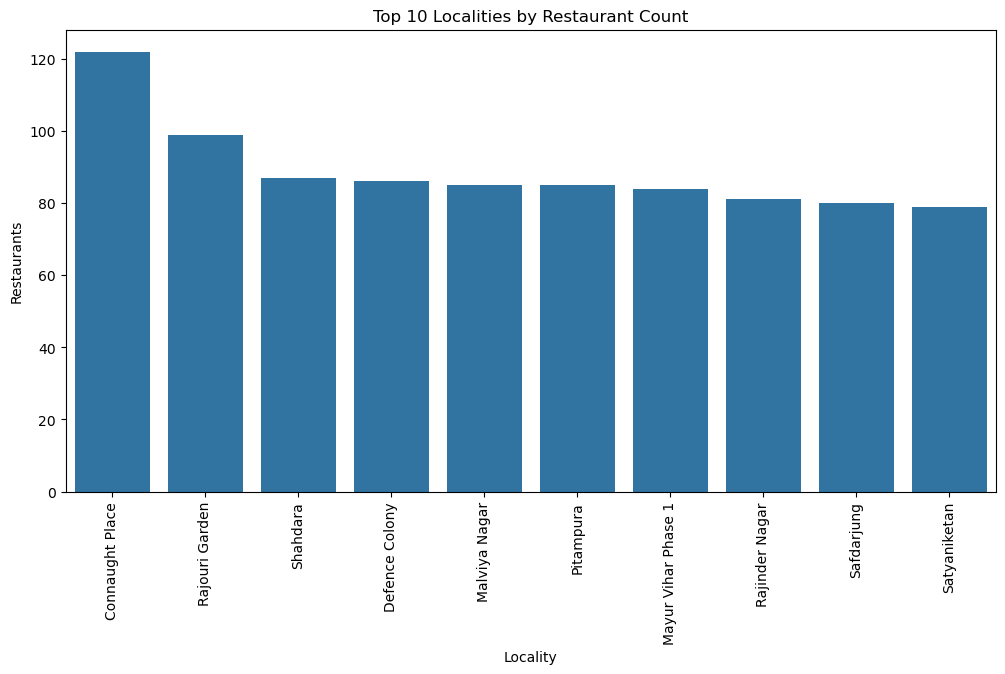

In [14]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=locality_counts.index,
    y=locality_counts.values
)

plt.title("Top 10 Localities by Restaurant Count")
plt.xlabel("Locality")
plt.ylabel("Restaurants")

plt.xticks(rotation=90)

plt.show()

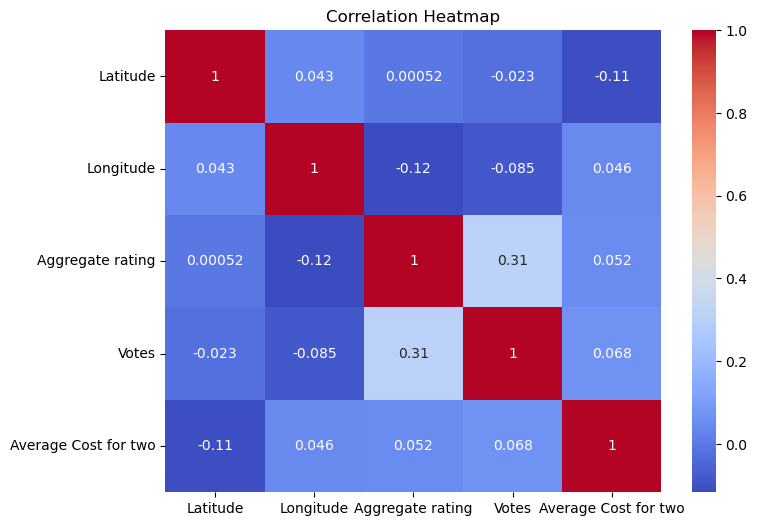

In [15]:
plt.figure(figsize=(8,6))

numeric_cols = [
    'Latitude',
    'Longitude',
    'Aggregate rating',
    'Votes',
    'Average Cost for two'
]

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [21]:

import folium

map_center = [
    df['Latitude'].mean(),
    df['Longitude'].mean()
]

restaurant_map = folium.Map(
    location=map_center,
    zoom_start=5
)

for i in range(min(100, len(df))):
    folium.Marker(
        [
            df.iloc[i]['Latitude'],
            df.iloc[i]['Longitude']
        ]
    ).add_to(restaurant_map)

restaurant_map


print("Result:")
print("Location-based analysis identified cities and localities with the highest restaurant concentration. Geographic visualization using latitude and longitude revealed restaurant distribution patterns, while city-level analysis highlighted differences in ratings and average costs across locations.")

Result:
Location-based analysis identified cities and localities with the highest restaurant concentration. Geographic visualization using latitude and longitude revealed restaurant distribution patterns, while city-level analysis highlighted differences in ratings and average costs across locations.
